### Predicción del precio de autos Toyota Corrolla usados

#### 0 Importar las librerias que necesitamos

In [2]:
! pip install pandas numpy statsmodels matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
#### Importamos las paqueterias necesarias
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from itertools import combinations
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

#### 1 Cargamos la base de datos y realizamos un reporte

In [4]:
# Cargamos el dataset
car_df=pd.read_csv("ToyotaCorolla (1).csv")

In [5]:
# Visualizamos la información del dataset
car_df.info

<bound method DataFrame.info of                                                   model  price  age_08_04  \
0         TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13500         23   
1         TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13750         23   
2         TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13950         24   
3         TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  14950         26   
4           TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors  13750         30   
...                                                 ...    ...        ...   
1431         TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors   7500         69   
1432  TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...  10845         72   
1433  TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...   8500         71   
1434  TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...   7250         70   
1435        TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors   6950         76   

      mfg_month  mfg_year     km fuel_type 

In [6]:
#Verificar si hay duplicados en la base de datos
# Eliminamos los duplicados
car_df.duplicated().sum()


np.int64(1)

In [7]:
car_df=car_df.drop_duplicates()
car_df.duplicated().sum()


np.int64(0)

In [8]:
# Seleccionamos las variables de interés
car_df = car_df[['price', 'age_08_04', 'km', 'fuel_type',
                 'hp', 'met_color', 'automatic', 'cc', 'doors', 'quarterly_tax', 'weight']]
car_df.info()

<class 'pandas.DataFrame'>
Index: 1435 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   price          1435 non-null   int64
 1   age_08_04      1435 non-null   int64
 2   km             1435 non-null   int64
 3   fuel_type      1435 non-null   str  
 4   hp             1435 non-null   int64
 5   met_color      1435 non-null   int64
 6   automatic      1435 non-null   int64
 7   cc             1435 non-null   int64
 8   doors          1435 non-null   int64
 9   quarterly_tax  1435 non-null   int64
 10  weight         1435 non-null   int64
dtypes: int64(10), str(1)
memory usage: 134.5 KB


#### 2 Limpiamos la base de datos con base en el reporte: duplicados y errores obvios

In [9]:
# Transformamos la variable fuel_type en variables dicotómicas con ceros y unos
car_df=pd.get_dummies(
    car_df,
    columns=['fuel_type'],
    dtype=int
)
car_df.head()


,price,age_08_04,km,hp,met_color,automatic,cc,doors,quarterly_tax,weight,fuel_type_CNG,fuel_type_Diesel,fuel_type_Petrol
0,13500,23,46986,90,1,0,2000,3,210,1165,0,1,0
1,13750,23,72937,90,1,0,2000,3,210,1165,0,1,0
2,13950,24,41711,90,1,0,2000,3,210,1165,0,1,0
3,14950,26,48000,90,0,0,2000,3,210,1165,0,1,0
4,13750,30,38500,90,0,0,2000,3,210,1170,0,1,0


#### 3 Partimos la base de datos en conjunto de entrenamiento y prueba

In [10]:
# Identificamos la variable de interés y las variables predictoras
X = car_df.drop('price', axis=1)
y = car_df['price']

# Hacemos el split de la base de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [11]:
X_train.head()

,age_08_04,km,hp,met_color,automatic,cc,doors,quarterly_tax,weight,fuel_type_CNG,fuel_type_Diesel,fuel_type_Petrol
1128,78,109263,110,0,0,1600,5,85,1070,0,0,1
899,62,59295,86,0,0,1300,5,69,1035,0,0,1
1188,71,90370,86,1,0,1300,5,69,1035,0,0,1
311,44,38461,110,1,0,1600,5,85,1080,0,0,1
1145,75,101855,110,1,0,1600,5,85,1070,0,0,1


In [12]:
y_train.head()

1128     7500
899      9500
1188     7950
311     13995
1145     6450
Name: price, dtype: int64

#### 4 Limpiamos el conjunto de entranamiento: outliers, missing, escalamiento, etc.

In [13]:
#Tabla descriptivos
X_train.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age_08_04,1148.0,55.82,18.70,1.0,44.0,60.5,70.00,80.0
km,1148.0,69219.57,37795.18,1.0,43683.0,64000.0,87130.75,243000.0
hp,1148.0,101.47,15.04,69.0,90.0,110.0,110.00,192.0
met_color,1148.0,0.66,0.47,0.0,0.0,1.0,1.00,1.0
automatic,1148.0,0.05,0.22,0.0,0.0,0.0,0.00,1.0
cc,1148.0,1580.22,465.46,1300.0,1400.0,1600.0,1600.00,16000.0
doors,1148.0,4.03,0.95,2.0,3.0,4.0,5.00,5.0
quarterly_tax,1148.0,87.11,40.78,19.0,69.0,85.0,85.00,283.0
weight,1148.0,1072.19,50.60,1000.0,1040.0,1070.0,1085.00,1480.0
fuel_type_CNG,1148.0,0.01,0.11,0.0,0.0,0.0,0.00,1.0


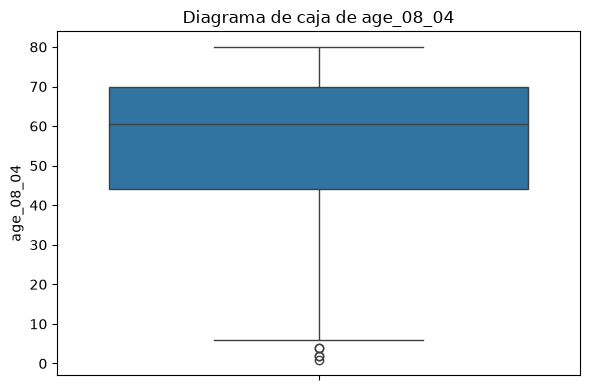

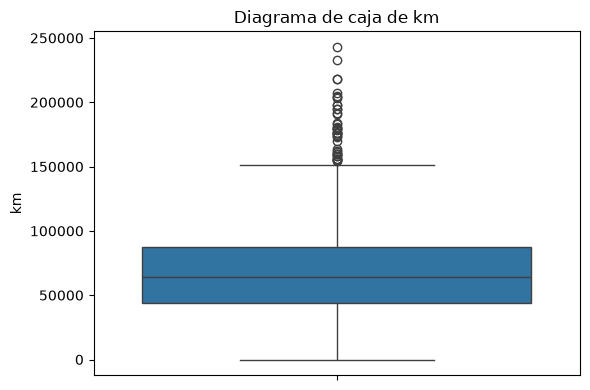

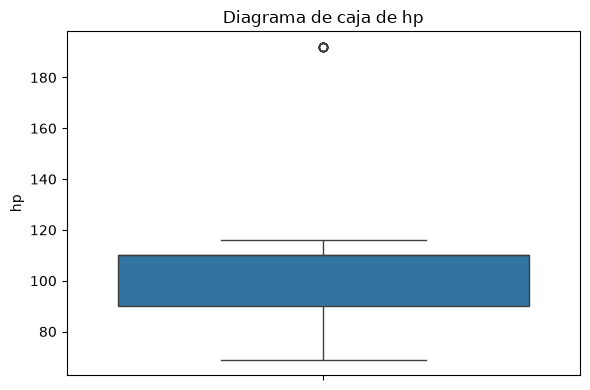

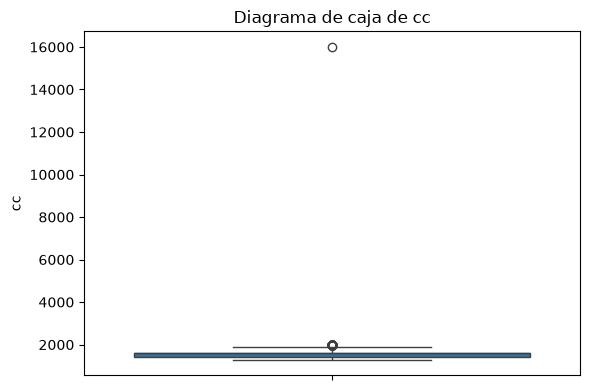

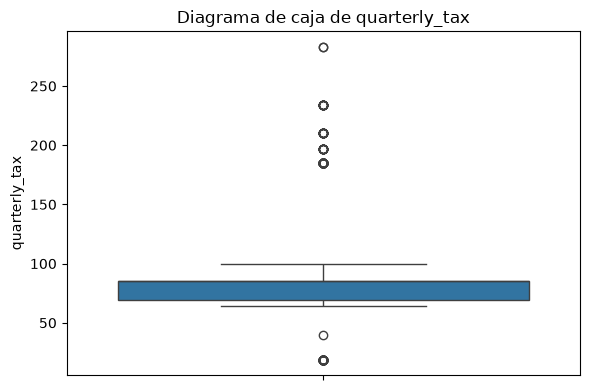

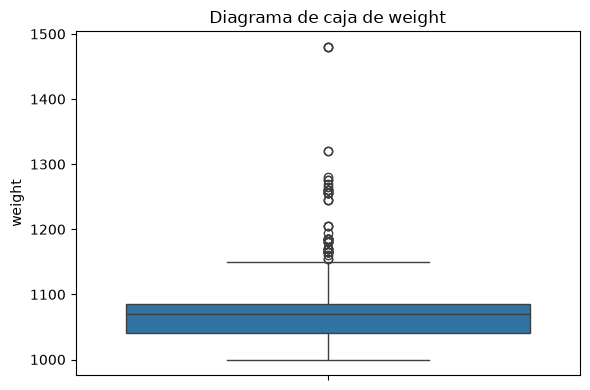

In [14]:
# Boxplot

variables_boxplot = ['age_08_04', 'km', 'hp', 'cc', 'quarterly_tax', 'weight']

for variable in variables_boxplot:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=X_train[variable])
    plt.title(f'Diagrama de caja de {variable}')
    plt.ylabel(variable)
    plt.tight_layout()
    plt.show()



In [15]:
# Aplicamos wenserización para tratar los outliers conjunto de entrenamiento
for col in ['age_08_04', 'km', 'hp', 'cc', 'quarterly_tax', 'weight']:
    X_train[col] = X_train[col].clip(lower=X_train[col].quantile(0.01), upper=X_train[col].quantile(0.99))
# Aplicamos wenserización para tratar los outliers de price
y_train = y_train.clip(lower=y_train.quantile(0.01), upper=y_train.quantile(0.99))

In [16]:

# Aplicamos wenserización para tratar los outliers de price

!pip install feature-engine
from feature_engine. outliers import Winsorizer

winsorizer = Winsorizer(
    capping_method='quantiles',
    tail= "both",
    fold=0.01, # Corta el 1% inferior y superior (1% y 99%)
    variables=["age_08_04", "km", "hp", "cc", "quarterly_tax", "weight"]
)
# Ajusta en train y transforma ambos
X_train = winsorizer. fit_transform(X_train)
X_test = winsorizer.transform(X_test)



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [17]:
X_train.describe().round(2)

,age_08_04,km,hp,met_color,automatic,cc,doors,quarterly_tax,weight,fuel_type_CNG,fuel_type_Diesel,fuel_type_Petrol
count,1148.00,1148.00,1148.00,1148.00,1148.00,1148.00,1148.00,1148.00,1148.00,1148.00,1148.00,1148.00
mean,55.84,69080.04,100.87,0.66,0.05,1568.03,4.03,87.02,1071.46,0.01,0.11,0.88
std,18.62,37055.33,12.77,0.47,0.22,188.08,0.95,40.42,46.36,0.11,0.31,0.33
min,8.00,4719.10,69.00,0.00,0.00,1300.00,2.00,19.00,1000.00,0.00,0.00,0.00
25%,44.00,43683.00,90.00,0.00,0.00,1400.00,3.00,69.00,1040.00,0.00,0.00,1.00
50%,60.50,64000.00,110.00,1.00,0.00,1600.00,4.00,85.00,1070.00,0.00,0.00,1.00
75%,70.00,87130.75,110.00,1.00,0.00,1600.00,5.00,85.00,1085.00,0.00,0.00,1.00
max,80.00,192441.63,116.00,1.00,1.00,2000.00,5.00,234.00,1260.00,1.00,1.00,1.00


Text(0.5, 1.0, 'Diagrama de caja de price')

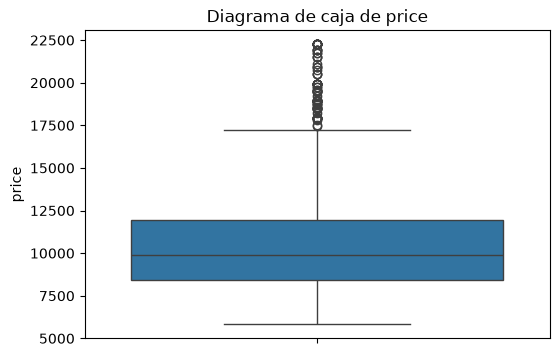

In [18]:
#Ahora la variable objetivo price, diagrama de caja
plt.figure(figsize=(6, 4))
sns. boxplot(y=y_train)
plt.title('Diagrama de caja de price')

In [19]:
y_train.describe().round(2)

count     1148.00
mean     10706.12
std       3519.93
min       5821.15
25%       8450.00
50%       9900.00
75%      11950.00
max      22250.00
Name: price, dtype: float64

In [20]:
# 1. Definimos los límites usando solo y_train
lower_limit = y_train.quantile(0.01)
upper_limit = y_train.quantile(0.99)
# 2. Aplicamos el recorte SOLO a y_train
y_train = y_train. clip(lower=lower_limit, upper=upper_limit)
# y_test se mantiene intacto para la evaluación real

In [21]:
y_train.describe().round(2)

count     1148.00
mean     10706.23
std       3519.77
min       5832.36
25%       8450.00
50%       9900.00
75%      11950.00
max      22250.00
Name: price, dtype: float64

#### 5 Corremos el modelo de regresión lineal múltiple

Codigo bien de aqui para abajo 

In [22]:
# Aplicamos RLM para predecir el precio de los autos
X_train_const=sm.add_constant(X_train)
rlm_model=sm.RLM(y_train,X_train_const, M=sm.robust.norms.HuberT())
rlm_results=rlm_model.fit()
print(rlm_results.summary())


                    Robust Linear Model Regression Results                    
Dep. Variable:                  price   No. Observations:                 1148
Model:                            RLM   Df Residuals:                     1136
Method:                          IRLS   Df Model:                           11
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Fri, 02 Oct 2026                                         
Time:                        22:11:53                                         
No. Iterations:                     8                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.563e+04   1147.734  

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:334: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = lm.WLS(self.endog, self.exog).fit()


In [23]:
# Evalumos el rendimeinto del modelo con el conjunto de entrenamiento
X_train_const = sm.add_constant(X_train)
rlm_model = sm.RLM(y_train, X_train_const, M=sm.robust.norms.HuberT())
rlm_results = rlm_model.fit()
print(rlm_results.summary())



                    Robust Linear Model Regression Results                    
Dep. Variable:                  price   No. Observations:                 1148
Model:                            RLM   Df Residuals:                     1136
Method:                          IRLS   Df Model:                           11
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Fri, 02 Oct 2026                                         
Time:                        22:11:53                                         
No. Iterations:                     8                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.563e+04   1147.734  

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:334: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = lm.WLS(self.endog, self.exog).fit()


In [24]:
# Precio promedio de los autos en el conjunto de entrenamiento
precio_promedio = y_train.mean()
print (f"Precio promedio de los autos en el conjunto de entrenamiento: (precio_promedio: 2f)")

Precio promedio de los autos en el conjunto de entrenamiento: (precio_promedio: 2f)


##### 📈 Interpretación de las métricas del modelo con entrenamiento

##### R² = 0.7579

El modelo explica aproximadamente **88% de la variabilidad** en el precio de los autos.
Esto indica un **muy buen ajuste dentro de muestra**, ya que una proporción alta de la variación del precio está siendo capturada por las variables explicativas.

---

##### MAE = 906.79

En promedio, el modelo se equivoca en aproximadamente **$907 dólares** por auto.
Si el precio promedio es cercano a 10,700, el error relativo es: 8.4% aprox.
Es decir, el modelo comete un error promedio cercano al **9% del precio**, lo cual es bastante razonable en modelos de precios de autos.

---

##### RMSE = 1220.19

El RMSE penaliza más los errores grandes.
El hecho de que: RMSE > MAE, indica que existen algunos errores relativamente grandes (outliers o autos con características difíciles de modelar).
Sin embargo, la diferencia no es extrema, lo que sugiere que el modelo no presenta errores desproporcionadamente altos.

#### 6 Validación cruzada con el modelo del conjunto de entrenamiento

In [25]:
# Aplicamos validación cruzada para evaluar el modelo 
from sklearn.model_selection import cross_val_score 
from sklearn.linear_model import HuberRegressor
huber_cv_model = HuberRegressor ()
cv_scores = cross_val_score (huber_cv_model, X, y, cv=5, scoring='neg_mean_absolute_error')
print (f"MAE Cross-Validation Scores: {-cv_scores}")
print (f"Average MAE: {-cv_scores.mean():.2f}")

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


MAE Cross-Validation Scores: [2318.61835587 1107.26133777  855.90156492  859.35283014  873.89912261]
Average MAE: 1203.01


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/python/3.12.1/lib/python3.12/si

In [30]:
print(f"MAE Cross-Validation Scores: {-cv_scores}")
print(f"Average MAE: {-cv_scores.mean():.2f}")

MAE Cross-Validation Scores: [2318.61835587 1107.26133777  855.90156492  859.35283014  873.89912261]
Average MAE: 1203.01


#### 📊 Interpretación de Resultados – Validación Cruzada (MAE)

**Precio promedio del producto:** $10,700  

##### Resultados obtenidos

MAE por fold:
- 2318.06  
- 1105.57  
- 856.35  
- 867.24  
- 877.05  

**MAE promedio:** 1204.85  

---

##### Interpretación del MAE

El **MAE (Mean Absolute Error)** indica que, en promedio, el modelo comete un error de aproximadamente **$1,205 pesos** por predicción.

En términos relativos:

\[
\frac{1204.85}{10700} \approx 11.3\%
\]

Esto significa que el modelo tiene un error promedio cercano al **11% del precio promedio**, lo cual es razonable dependiendo del contexto del mercado y la variabilidad natural de los precios.

---

##### Estabilidad del modelo

Se observa que:

- Cuatro folds presentan errores relativamente similares (entre $856 y $1,105).
- Un fold presenta un error considerablemente mayor ($2,318).

Esto sugiere que el modelo es **generalmente estable**, pero existe cierta sensibilidad a la composición de la muestra en uno de los subconjuntos.

Posibles razones:
- Presencia de outliers en ese fold.
- Segmentos de mercado con comportamiento distinto.
- No linealidad no capturada completamente por el modelo.

---

##### Diagnóstico técnico

✔ El modelo muestra desempeño consistente en la mayoría de los folds.  
⚠ Existe cierta variabilidad que podría indicar:
- Sensibilidad a valores extremos.
- Posible mejora con modelos no lineales.
- Oportunidad de aplicar técnicas robustas o transformaciones.

---

##### Conclusión

El modelo presenta un desempeño aceptable con un error promedio cercano al 11% del precio medio.  
Sin embargo, la variabilidad entre folds sugiere que podría mejorarse mediante:

- Tratamiento de outliers
- Transformaciones (log del precio)
- Modelos más flexibles (árboles o ensambles)

#### 7 Aplicamos los mismos cambios del conjunto de entrenamiento al conjunto prueba: limpiar outliers, etc.

In [33]:
# Aplicamos winserización para tratar los outliers en el conjunto de prueba pero con los parametros del conjunto de entrenamiento


#### 8 Evaluamos desempeño pero con el conjunto de prueba

In [31]:
# Calculamos las predicciones del modelo utilizando el conjunto de prueba
X_test_const = sm.add_constant(X_test)
y_pred = rlm_results.predict(X_test_const)
# Tabla con los valores reales, las predicciones y los errores
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Error': y_test - y_pred
})
print(results_df.head().round(2))

      Actual  Predicted    Error
753     9950   10475.64  -525.64
858     7995   10264.26 -2269.26
630     7500    9400.68 -1900.68
1412    9950    9303.09   646.91
975     8950    8850.04    99.96


In [34]:
# Analizamos las metricas mae, rmse, error medio y r2
mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)
print("Métricas de RLM:")
print(f"RMSE: {rmse_lr:.2f}")
print(f"MAE: {mae_lr:.2f}")
print(f"Error Medio: {np.mean(np.abs(y_test - y_pred)):.2f}")
print(f"R²: {r2_lr:.4f}")

Métricas de RLM:
RMSE: 1407.25
MAE: 965.79
Error Medio: 965.79
R²: 0.8349


In [35]:
# precio promedio de los autos
precio_promedio = y_test. mean()
print(f"Precio promedio de los autos: {precio_promedio:.2f}")

Precio promedio de los autos: 10696.39


#### 9 📈 Interpretación de las métricas del modelo con conjunto prueba

##### R² = 0.88

El modelo explica aproximadamente **88% de la variabilidad** en el precio de los autos.
Esto indica un **muy buen ajuste dentro de muestra**, ya que una proporción alta de la variación del precio está siendo capturada por las variables explicativas.

---

##### MAE = 893.64

En promedio, el modelo se equivoca en aproximadamente **$894 dólares** por auto.
Si el precio promedio es cercano a 10,669, el error relativo es: approx 8.3%.
Es decir, el modelo comete un error promedio cercano al **8%-9% del precio**, lo cual es bastante razonable en modelos de precios de autos.

---

#### RMSE = 1183.8

El RMSE penaliza más los errores grandes.

El hecho de que: RMSE > MAE indica que existen algunos errores relativamente grandes (outliers o autos con características difíciles de modelar).
Sin embargo, la diferencia no es extrema, lo que sugiere que el modelo no presenta errores desproporcionadamente altos.

---

#### Diagnóstico general

✔ El modelo presenta **alta capacidad explicativa (R² alto)**  
✔ El error promedio es **moderado (≈ 8–9%)**  
✔ Existen algunos errores grandes, pero no dominantes  

En conjunto, la Regresión Lineal ofrece un desempeño sólido para predicción de precios, aunque podría mejorar si se capturan posibles **relaciones no lineales** o **interacciones** entre variables.

---

#### Conclusión

El modelo lineal logra explicar gran parte de la variación en los precios y mantiene un error promedio razonable.  
No obstante, dado que los precios suelen presentar comportamientos no lineales (edad, kilometraje, segmento del vehículo), podría explorarse el uso de modelos más flexibles como árboles de regresión para comparar desempeño.